data cleaning in python is done using pandas, handling null values, dropping missing values,
dropping columns with wrong data, filling null values, all things part of cleaning.

In [2]:
import pandas as pd
df=pd.read_csv('North America Restaurants (1).csv')

In [9]:
import pandas as pd
import numpy as np

data={
    'employee':['asha','chitra','deepa','esha','farhan'],
    'department':['hr','It','finance','hr','IT'],
    'age':[25,32,np.nan,41,np.nan],
    'salary':[40000,80000,55000,np.nan,50000],
    'performance_score':[85,90,78,np.nan,88]

}
df=pd.DataFrame(data)
df

,employee,department,age,salary,performance_score
0,asha,hr,25.0,40000.0,85.0
1,chitra,It,32.0,80000.0,90.0
2,deepa,finance,NaN,55000.0,78.0
3,esha,hr,41.0,NaN,NaN
4,farhan,IT,NaN,50000.0,88.0


In [10]:
#count of missing values column-wise
df.isna().sum()

employee             0
department           0
age                  2
salary               1
performance_score    1
dtype: int64

In [12]:
df.isna()

,employee,department,age,salary,performance_score
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,True,True
4,False,False,True,False,False


In [ ]:
#rows with missing columns
df[df.isna().any(axis=1)]

,employee,department,age,salary,performance_score
2,deepa,finance,NaN,55000.0,78.0
3,esha,hr,41.0,NaN,NaN
4,farhan,IT,NaN,50000.0,88.0


Axis tells which direction to move in for pandas 


rows->move horizontally
columns go vertically 

there are only two possible axes:
axis=0 means operate down rows (column-wise)
aaxis=1 means operate across the columns (row-wise)

In [13]:
#dropping missing values 
df.dropna()

#drop any rows with missing values 

,employee,department,age,salary,performance_score
0,asha,hr,25.0,40000.0,85.0
1,chitra,It,32.0,80000.0,90.0


In [ ]:
df.dropna(how='all')

#drops any row which has all values missing
#how=all is strict delection

,employee,department,age,salary,performance_score
0,asha,hr,25.0,40000.0,85.0
1,chitra,It,32.0,80000.0,90.0
2,deepa,finance,NaN,55000.0,78.0
3,esha,hr,41.0,NaN,NaN
4,farhan,IT,NaN,50000.0,88.0


In [16]:
#based on threshold
df.dropna(thresh=4)

#keep rwos with atleast 4 non-null values

,employee,department,age,salary,performance_score
0,asha,hr,25.0,40000.0,85.0
1,chitra,It,32.0,80000.0,90.0
2,deepa,finance,NaN,55000.0,78.0
4,farhan,IT,NaN,50000.0,88.0


In [17]:
#drop columns with missing values
df.dropna(axis=1)

,employee,department
0,asha,hr
1,chitra,It
2,deepa,finance
3,esha,hr
4,farhan,IT


imputation-filling missing values
inpython both np.nan and none are missing data

np,nan stands for not a number
None is for missing data

when do we drop?
drop when missing values are very small,
example-dataset has 100000 rows, only 30 rows contain missing values, dropping them wont affect analysit

entire column is useless or unnecessary dataor maybe entrire column is empty

when will dropping be a problem?
when dropping we remove other valuable information too, to avoide this we prefer filling in some cases


types of imputation
-mean imputation
-median imputation
-mode imputation
-time series imputation

dropping can some time redudce datasets size and dropping them might not make sense

dropping is better when there are too many missing values in a column,

some time missing values might be imortant 
example -
ina loan dataset

income-nan
loan defult-yes

missing income means it might be risky to provide loan and dropping this row means losing important information

In [6]:
import pandas as pd
import numpy as np

data={
    'customer_name':['asha','bala','chitra','deepa','esha','bala'],
    'city':['bangalore','delhi',None,'delhi','bangalore','mumbai'],
    'order_value':[5000,7000,np.nan,6500,7200,7000],
    'order_date':['2024-01-01','2024-01-02',None,'2024-01-04','2024-01-05','2024-01-02'],
    'email':['asha123@gmail.com','bala@gmail.com','chitra@company.com',
             'deepa_98@yahoo.com','esha@gmail.com','bala@gmail.com']
}

df=pd.DataFrame(data)
df

,customer_name,city,order_value,order_date,email
0,asha,bangalore,5000.0,2024-01-01,asha123@gmail.com
1,bala,delhi,7000.0,2024-01-02,bala@gmail.com
2,chitra,NaN,NaN,NaN,chitra@company.com
3,deepa,delhi,6500.0,2024-01-04,deepa_98@yahoo.com
4,esha,bangalore,7200.0,2024-01-05,esha@gmail.com
5,bala,mumbai,7000.0,2024-01-02,bala@gmail.com


10,20,30,40,50
         30
    20        40
10            50

mean=30
median=30
mode=30

-mean imputation
mean uses all data points ans since data is balanced is represents the centre acuuratley

use when-
data is numerical
distribution is symetric
no extreme outliers
example-heghts:165,168,170, nan ,172
in thos case we can fill with mean


Salaries:40000,42000,45000,47000,900000

ouliers are extreme values that are very different from the rest of the data

the values 90000 is an outlier here.

normal salaries: 40k-47k
outlier:900k

when there are outlier in the data mean will become distorted 
and value will be unrealistics


skewed distribution
left-skewed
right-skewed

A distribution becomes skewed when outlier pull data towrd one side 

most values ->left side
one hue value ->right side

this is right skewed distribution
mean gets dragged towards the right side

median will stay stable

median works better when 
data is skewed 
outliers exist 
numeric data

mode imputation

mode=most freqant value

use for categorical data

cities: bangalore, delhi , delhi, mumbai, nan
fill missing value with most common category


time series imputation

time series data has time order 

data        sales
----        ----

da1          100
day2         nan
day3         105

here we use forward fill or interpolation

day2=day 1
becuase time changes gradully so yesterdays values is often the best estimate


use when data is tme based 
observations are seuquential
values change gradully

example:
stock prices
temperature sensores
electricity usage
wedsite traffic

In [ ]:
#missing order value
df['order_value'].fillna(df['order_value'].mean())

#replace missing order value with average order value


0    5000.0
1    7000.0
2    6540.0
3    6500.0
4    7200.0
5    7000.0
Name: order_value, dtype: float64

In [ ]:
#categorical data

df['city'].fillna(df['city'].mode()[0]) #mode is most repeating value replace

#when ther are multipule modes
#[0] will fill it with the first entry

0    bangalore
1        delhi
2    bangalore
3        delhi
4    bangalore
5       mumbai
Name: city, dtype: str

In [11]:
#time series data

#suppose daily oeder value is missing
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_date']=df['order_date'].ffill()
df

#when it comes to data datatype it is best to convert the datetime datatype
#becacuse sometime the data column might be set to string type
#so you have to convert to datetime datatype

,customer_name,city,order_value,order_date,email
0,asha,bangalore,5000.0,2024-01-01,asha123@gmail.com
1,bala,delhi,7000.0,2024-01-02,bala@gmail.com
2,chitra,NaN,NaN,2024-01-02,chitra@company.com
3,deepa,delhi,6500.0,2024-01-04,deepa_98@yahoo.com
4,esha,bangalore,7200.0,2024-01-05,esha@gmail.com
5,bala,mumbai,7000.0,2024-01-02,bala@gmail.com


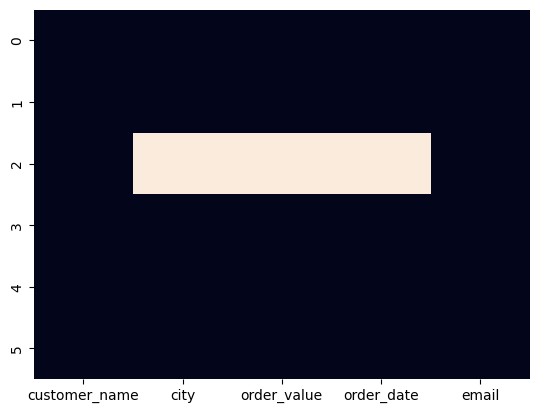

,customer_name,city,order_value,order_date,email
0,asha,bangalore,5000.0,2024-01-01,asha123@gmail.com
1,bala,delhi,7000.0,2024-01-02,bala@gmail.com
2,chitra,NaN,NaN,NaN,chitra@company.com
3,deepa,delhi,6500.0,2024-01-04,deepa_98@yahoo.com
4,esha,bangalore,7200.0,2024-01-05,esha@gmail.com
5,bala,mumbai,7000.0,2024-01-02,bala@gmail.com


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data={
    'customer_name':['asha','bala','chitra','deepa','esha','bala'],
    'city':['bangalore','delhi',None,'delhi','bangalore','mumbai'],
    'order_value':[5000,7000,np.nan,6500,7200,7000],
    'order_date':['2024-01-01','2024-01-02',None,'2024-01-04','2024-01-05','2024-01-02'],
    'email':['asha123@gmail.com','bala@gmail.com','chitra@company.com',
             'deepa_98@yahoo.com','esha@gmail.com','bala@gmail.com']
}

df=pd.DataFrame(data)
sns.heatmap(df.isna(),cbar=False)
plt.show()
df

sns.heatmap converts df.isna matrix here to colors so missing values appear as highlighted cells.

analysts use heatmaps in EDA (exploratory data analysis)

cbra=color bar(legend)

cbar is set to false because we have only true or false values so color scale is unneccessary

In [14]:
#time series imputation
#interpolate

data={'order_date':['2024-01-01','2024-01-02',None,'2024-01-04','2024-01-05'],
      'Sales':[100,np.nan,110,np.nan,120]
    }
df=pd.DataFrame(data)
df['order_date']=pd.to_datetime(df['order_date'])
df

,order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,NaN
2,NaT,110.0
3,2024-01-04,NaN
4,2024-01-05,120.0


In [12]:
df['Sales']=df['Sales'].ffill()
df

,order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,110.0
2,NaT,110.0
3,2024-01-04,120.0
4,2024-01-05,120.0


In [11]:
df['Sales']=df['Sales'].bfill()
df

,order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,110.0
2,NaT,110.0
3,2024-01-04,120.0
4,2024-01-05,120.0


In [15]:
#interpolation estimattes the values between two known points
df['Sales']=df['Sales'].interpolate()
df

,order_date,Sales
0,2024-01-01,100.0
1,2024-01-02,105.0
2,NaT,110.0
3,2024-01-04,115.0
4,2024-01-05,120.0
